# 📊 Comparativa de Rendimiento: StructType vs inferSchema
En este notebook vamos a comparar los tiempos de ejecución entre usar un esquema definido (`StructType`) y dejar que Spark lo infiera (`inferSchema=True`).

Mediremos tres fases:
1. **Carga de datos**
2. **Transformaciones perezosas**
3. **Acciones reales**


In [9]:
!pip install matplotlib numpy


  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 9.5 MB/s  0:00:00 eta 0:00:01
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 10.5 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 13.1 MB/s  0:00:00 eta 0:00:01
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]


In [1]:
import time
from pyspark.sql import SparkSession
from pyspark.sql.types import StructType, StructField, IntegerType, StringType, FloatType
from pyspark.sql import functions as F

# Iniciamos sesión de Spark
spark = SparkSession.builder \
    .appName("Comparativa_StructType_vs_inferSchema") \
    .master("local[*]") \
    .getOrCreate()


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/03/26 17:20:28 WARN Utils: Your hostname, MacBook-Pro-de-Juan.local, resolves to a loopback address: 127.0.0.1; using 172.20.37.199 instead (on interface en0)
26/03/26 17:20:28 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/26 17:20:30 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/03/26 17:20:31 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


In [2]:
# Esquema manual 
schema = StructType([
    StructField("student_id", IntegerType(), True),
    StructField("age", IntegerType(), True),
    StructField("gender", StringType(), True),
    StructField("study_hours_per_day", FloatType(), True),
    StructField("sleep_hours", FloatType(), True),
    StructField("phone_usage_hours", FloatType(), True),
    StructField("social_media_hours", FloatType(), True),
    StructField("youtube_hours", FloatType(), True),
    StructField("gaming_hours", FloatType(), True),
    StructField("breaks_per_day", IntegerType(), True),
    StructField("coffee_intake_mg", IntegerType(), True),
    StructField("exercise_minutes", IntegerType(), True),
    StructField("assignments_completed", IntegerType(), True),
    StructField("attendance_percentage", FloatType(), True),
    StructField("stress_level", IntegerType(), True),
    StructField("focus_score", IntegerType(), True),
    StructField("final_grade", FloatType(), True),
    StructField("productivity_score", FloatType(), True)
])

csv_path = "student_productivity_distraction_dataset_20000.csv"


## FASE 1: Carga de Datos


In [3]:
print("--- FASE 1: CARGA DE DATOS ---")

# inferSchema
t0 = time.time()
df_infer = spark.read.csv(csv_path, header=True, inferSchema=True)
t_load_infer = time.time() - t0
print(f"⏱️  Tiempo de carga con inferSchema=True: {t_load_infer:.4f}s")

# StructType
t0 = time.time()
df_struct = spark.read.csv(csv_path, header=True, schema=schema)
t_load_struct = time.time() - t0
print(f"⏱️  Tiempo de carga con StructType: {t_load_struct:.4f}s")


--- FASE 1: CARGA DE DATOS ---
⏱️  Tiempo de carga con inferSchema=True: 3.8980s
⏱️  Tiempo de carga con StructType: 0.0402s


## FASE 2: Transformaciones (Lazy Evaluation)


In [4]:
print("--- FASE 2: TRANSFORMACIONES ---")

def aplicar_transformaciones(df, nombre_metodo):
    # 1. Filtramos por estrés alto. 
    t0_f = time.time()
    df_filtered = df.filter(F.col("stress_level") > 8)
    t_f = time.time() - t0_f
    
    # 2. Nueva columna productivo
    t0_c = time.time()
    df_with_new_col = df_filtered.withColumn("es_productivo", F.col("productivity_score") > 60)
    t_c = time.time() - t0_c
    
    # 3. Select
    t0_s = time.time()
    df_final = df_with_new_col.select("student_id", "age", "gender", "stress_level", "es_productivo")
    t_s = time.time() - t0_s
    
    total_trans = t_f + t_c + t_s
    
    print(f"[{nombre_metodo}] Tiempo filtro: {t_f:.6f}s")
    print(f"[{nombre_metodo}] Tiempo crear nueva columna: {t_c:.6f}s")
    print(f"[{nombre_metodo}] Tiempo select: {t_s:.6f}s")
    print(f"[{nombre_metodo}] Total transformaciones: {total_trans:.6f}s\n")
    
    return df_final, total_trans, t_f, t_c, t_s

print("Midiendo tiempos de transformación para DataFrame cargado con inferSchema:")
df_final_infer, t_trans_infer, tf_inf, tc_inf, ts_inf = aplicar_transformaciones(df_infer, "inferSchema")

print("Midiendo tiempos de transformación para DataFrame cargado con StructType:")
df_final_struct, t_trans_struct, tf_st, tc_st, ts_st = aplicar_transformaciones(df_struct, "StructType")


--- FASE 2: TRANSFORMACIONES ---
Midiendo tiempos de transformación para DataFrame cargado con inferSchema:
[inferSchema] Tiempo filtro: 0.036739s
[inferSchema] Tiempo crear nueva columna: 0.035952s
[inferSchema] Tiempo select: 0.011738s
[inferSchema] Total transformaciones: 0.084429s

Midiendo tiempos de transformación para DataFrame cargado con StructType:
[StructType] Tiempo filtro: 0.008393s
[StructType] Tiempo crear nueva columna: 0.014740s
[StructType] Tiempo select: 0.006038s
[StructType] Total transformaciones: 0.029171s



## 📊 Comparativa de Transformaciones Individuales
En este gráfico vemos el desglose de cuánto tarda cada una de las operaciones perezosas en definirse.


In [ ]:
# Gráfica de desglose de transformaciones
ops = ['Filtro', 'Columna', 'Select']
tiempos_inf = [tf_inf, tc_inf, ts_inf]
tiempos_st = [tf_st, tc_st, ts_st]

x = np.arange(len(ops))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, tiempos_inf, width, label='inferSchema', color='#ffbe0b')
rects2 = ax.bar(x + width/2, tiempos_st, width, label='StructType', color='#8338ec')

ax.set_ylabel('Tiempo (segundos)')
ax.set_title('Desglose de Transformaciones (Lazy)')
ax.set_xticks(x)
ax.set_xticklabels(ops)
ax.legend()

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()


## FASE 3: Acciones
Aquí es donde Spark finalmente ejecuta el plan. Aquí veremos cuál de los dos es en general más rápido luego de ejecutar todo el plan.


In [14]:
print("--- FASE 3: ACCIONES ---")

def ejecutar_acciones(df, nombre_metodo):
    # count()
    t0 = time.time()
    total = df.count()
    t_count = time.time() - t0
    
    # show()
    t0 = time.time()
    df.show(5)
    t_show = time.time() - t0
    
    total_acciones = t_count + t_show
    
    print(f"[{nombre_metodo}] Tiempo count(): {t_count:.4f}s")
    print(f"[{nombre_metodo}] Tiempo show(5): {t_show:.4f}s")
    print(f"[{nombre_metodo}] Total acciones: {total_acciones:.4f}s\n")
    
    return total_acciones, t_count, t_show

print("Ejecutando acciones sobre el pipeline de inferSchema:")
t_acc_infer, tc_inf_acc, ts_inf_acc = ejecutar_acciones(df_final_infer, "inferSchema")

print("Ejecutando acciones sobre el pipeline de StructType:")
t_acc_struct, tc_st_acc, ts_st_acc = ejecutar_acciones(df_final_struct, "StructType")


--- FASE 3: ACCIONES ---
Ejecutando acciones sobre el pipeline de inferSchema:
+----------+---+------+------------+-------------+
|student_id|age|gender|stress_level|es_productivo|
+----------+---+------+------------+-------------+
|         1| 23|Female|          10|        false|
|         2| 20|  Male|          10|        false|
|         6| 29| Other|          10|        false|
|        10| 19|Female|          10|         true|
|        11| 23|  Male|          10|        false|
+----------+---+------+------------+-------------+
only showing top 5 rows
[inferSchema] Tiempo count(): 0.2004s
[inferSchema] Tiempo show(5): 0.2748s
[inferSchema] Total acciones: 0.4752s

Ejecutando acciones sobre el pipeline de StructType:
+----------+---+------+------------+-------------+
|student_id|age|gender|stress_level|es_productivo|
+----------+---+------+------------+-------------+
|         1| 23|Female|          10|        false|
|         2| 20|  Male|          10|        false|
|         6| 29

## ⚡ Comparativa de Acciones Reales
En este gráfico vemos el tiempo real que tarda Spark en ejecutar todo el plan acumulado hasta estas acciones.


NameError: name 'autolabel' is not defined

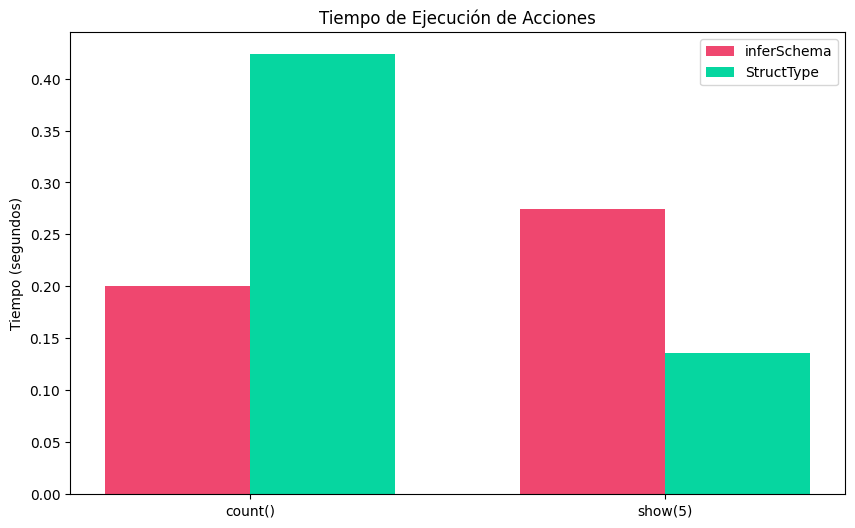

In [ ]:
# Gráfica de desglose de acciones
accs = ['count()', 'show(5)']
tiempos_inf_acc = [tc_inf_acc, ts_inf_acc]
tiempos_st_acc = [tc_st_acc, ts_st_acc]

x = np.arange(len(accs))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, tiempos_inf_acc, width, label='inferSchema', color='#ef476f')
rects2 = ax.bar(x + width/2, tiempos_st_acc, width, label='StructType', color='#06d6a0')

ax.set_ylabel('Tiempo (segundos)')
ax.set_title('Tiempo de Ejecución de Acciones')
ax.set_xticks(x)
ax.set_xticklabels(accs)
ax.legend()


plt.tight_layout()
plt.show()


## Resumen y Conclusión


In [6]:
print("=" * 60)
print("RESUMEN DE TIEMPOS (StructType vs inferSchema)")
print("=" * 60)
print(f"{'Fase':<20} | {'inferSchema':<15} | {'StructType':<15}")
print("-" * 60)
print(f"{'Carga de datos':<20} | {t_load_infer:<15.4f} | {t_load_struct:<15.4f}")
print(f"{'Transformaciones':<20} | {t_trans_infer:<15.4f} | {t_trans_struct:<15.4f}")
print(f"{'Acciones':<20} | {t_acc_infer:<15.4f} | {t_acc_struct:<15.4f}")
print("-" * 60)
print(f"{'TOTAL':<20} | {t_load_infer+t_trans_infer+t_acc_infer:<15.4f} | {t_load_struct+t_trans_struct+t_acc_struct:<15.4f}")
print("=" * 60)

mejora = (t_load_infer+t_trans_infer+t_acc_infer) - (t_load_struct+t_trans_struct+t_acc_struct)
if mejora > 0:
    print(f"🚀 Excelente: Usar StructType ha ahorrado un total de {mejora:.4f} segundos.")
else:
    print(f"ℹ️ Curiosamente, el StructType tardó {-mejora:.4f}s más (puede variar por lectura en caché del SO).")


RESUMEN DE TIEMPOS (StructType vs inferSchema)
Fase                 | inferSchema     | StructType     
------------------------------------------------------------
Carga de datos       | 3.8980          | 0.0402         
Transformaciones     | 0.0844          | 0.0292         
Acciones             | 1.2056          | 0.3810         
------------------------------------------------------------
TOTAL                | 5.1880          | 0.4503         
🚀 Excelente: Usar StructType ha ahorrado un total de 4.7377 segundos.


## 📈 Visualización de Resultados
A continuación, presentamos una gráfica comparativa para visualizar mejor la diferencia de rendimiento en cada fase.


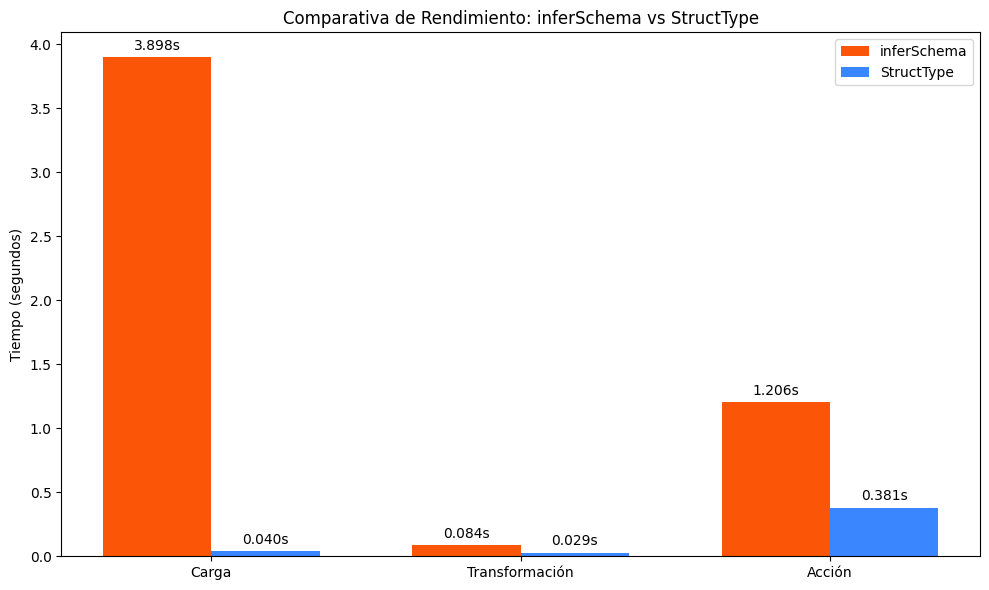

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Datos para la gráfica
fases = ['Carga', 'Transformación', 'Acción']
tiempos_infer = [t_load_infer, t_trans_infer, t_acc_infer]
tiempos_struct = [t_load_struct, t_trans_struct, t_acc_struct]

x = np.arange(len(fases))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, tiempos_infer, width, label='inferSchema', color='#fb5607')
rects2 = ax.bar(x + width/2, tiempos_struct, width, label='StructType', color='#3a86ff')

# Añadir etiquetas y estilo
ax.set_ylabel('Tiempo (segundos)')
ax.set_title('Comparativa de Rendimiento: inferSchema vs StructType')
ax.set_xticks(x)
ax.set_xticklabels(fases)
ax.legend()

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}s', 
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), 
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

fig.tight_layout()
plt.show()
